<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 04b — Score candidates with the upstream pipecat smart-turn model

Mirror of `04_score_own_model.ipynb`, but swap the model: instead of
loading our zh fine-tune from `checkpoints/smart-turn-zh/`, we pull
`pipecat-ai/smart-turn-v3` (the upstream multilingual baseline shipped
with pipecat) and score the same `candidates.parquet` with it.

Why bother:

- **Sanity check on probability spread.** Our zh model squashed every
  candidate into roughly `[0.35, 0.62]` — a strong hint it's
  undertrained on 1062 clips. If pipecat-v3 (trained on a much larger
  multilingual corpus) gives the same RAMC clips a wider, more
  decisive distribution, that confirms the squash is a data problem,
  not an architecture / pipeline bug.
- **Free third consensus signal.** The output column
  `pipecat_prob` / `pipecat_pred` can be fed to notebook 06 alongside
  the structural label and the LLM verdict. (Whether to *use* it as a
  signal is a separate decision — pipecat-v3 is multilingual but not
  zh-specialized, so its probabilities aren't necessarily better than
  ours, just differently biased.)

Implementation notes:

- Model is the **INT8 ONNX** shipping artifact (`smart-turn-v3.2-cpu.onnx`),
  fetched once via `hf_hub_download` and cached. Same architecture as
  ours — Whisper-tiny encoder + pooled binary head — so the input
  shape `(B, 80, 800)` is identical.
- Feature extractor is **`openai/whisper-tiny`**, not our checkpoint
  dir. Pipecat trained against vanilla Whisper-tiny preprocessing; if
  we feed it our checkpoint's FE the mel statistics drift and the
  output collapses.
- Audio path is identical to notebook 04: read each session WAV once,
  truncate each clip to the trailing 8 s, batch through the model.
  ONNXRuntime CPU is plenty fast for ~34K clips since the model is
  INT8.

## Configure paths

In [1]:
from pathlib import Path

MINING_ROOT       = Path("../../datasets/smart-turn-zh-mining").resolve()
CANDIDATES_IN     = MINING_ROOT / "candidates.parquet"
CANDIDATES_OUT    = MINING_ROOT / "candidates_pipecat.parquet"
WAV_DIR           = Path("../../datasets/MagicData-RAMC/MDT2021S003/WAV").resolve()

PIPECAT_REPO      = "pipecat-ai/smart-turn-v3"
PIPECAT_FILE      = "smart-turn-v3.2-cpu.onnx"   # INT8 shipping artifact
PIPECAT_FE        = "openai/whisper-tiny"        # upstream's preprocessing
PIPECAT_THRESHOLD = 0.5                          # pipecat ships 0.5 as default

SAMPLE_RATE   = 16_000
CHUNK_LENGTH  = 8           # seconds; same as ours / pipecat

print(f"candidates : {CANDIDATES_IN.name}")
print(f"out        : {CANDIDATES_OUT.name}")
print(f"wavs       : {WAV_DIR.name}")
print(f"model      : {PIPECAT_REPO}/{PIPECAT_FILE}")
print(f"feat extr  : {PIPECAT_FE}")
print("✅ paths configured")

candidates : candidates.parquet
out        : candidates_pipecat.parquet
wavs       : WAV
model      : pipecat-ai/smart-turn-v3/smart-turn-v3.2-cpu.onnx
feat extr  : openai/whisper-tiny
✅ paths configured


## Load pipecat ONNX + Whisper-tiny feature extractor

`hf_hub_download` caches the ONNX under `~/.cache/huggingface/hub/`,
so re-runs are local. ONNXRuntime's CPU provider is enough — the
INT8 model is ~8 MB and runs fast on a single thread.

We reuse `truncate_to_last_n_seconds` from `notebooks/smart-turn/smart_turn.py`
so the trailing-8-s slicing matches both 04 and the pipecat training
convention (smart-turn always looks at the *end* of an utterance).

In [2]:
import sys

import numpy as np
import onnxruntime as ort
from huggingface_hub import hf_hub_download
from transformers import WhisperFeatureExtractor

# Make ../smart-turn importable so we reuse truncate_to_last_n_seconds.
SMART_TURN_PKG = (Path("../smart-turn")).resolve()
if str(SMART_TURN_PKG) not in sys.path:
    sys.path.insert(0, str(SMART_TURN_PKG))

from smart_turn import truncate_to_last_n_seconds  # noqa: E402

onnx_path = hf_hub_download(repo_id=PIPECAT_REPO, filename=PIPECAT_FILE)
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
fe = WhisperFeatureExtractor.from_pretrained(PIPECAT_FE)

input_meta = sess.get_inputs()[0]
output_meta = sess.get_outputs()[0]

print(f"onnx file  : {Path(onnx_path).name}")
print(f"input  name={input_meta.name!r}  shape={input_meta.shape}  dtype={input_meta.type}")
print(f"output name={output_meta.name!r} shape={output_meta.shape} dtype={output_meta.type}")
print(f"threshold  : {PIPECAT_THRESHOLD:.2f}")
print("✅ pipecat onnx + feature extractor loaded")

onnx file  : smart-turn-v3.2-cpu.onnx
input  name='input_features'  shape=['s6', 80, 800]  dtype=tensor(float)
output name='logits' shape=['s6', 1] dtype=tensor(float)
threshold  : 0.50
✅ pipecat onnx + feature extractor loaded


## Load candidates

Same source file as notebook 04 — one row per candidate clip.
Sorted by `session_id` so the scoring loop reads each WAV exactly
once.

In [4]:
import pandas as pd

cand = pd.read_parquet(CANDIDATES_IN)
cand = cand.sort_values(["session_id", "candidate_idx"]).reset_index(drop=True)

print(f"candidates : {len(cand):,}")
print(f"sessions   : {cand['session_id'].nunique()}")
print(f"label dist :")
print(cand["label"].value_counts().to_string())
print("✅ candidates loaded")

candidates : 33,943
sessions   : 349
label dist :
label
0    19959
1    13984
✅ candidates loaded


## Audio + feature helpers

Same `read_wav_16k_mono` / `slice_clip` as notebook 04 (soundfile,
no torchaudio dep). The only feature-extraction difference is which
`fe` we feed it — here it's Whisper-tiny's preprocessor, not ours.

We call the FE with a single-element python list for each clip so
the returned tensor is `(1, 80, 800)` and we can stack a batch with
`np.concatenate` for ONNX.

In [5]:
import soundfile as sf

def read_wav_16k_mono(wav_path: Path) -> np.ndarray:
    """Read a 16 kHz mono RAMC WAV as float32 in [-1, 1]."""
    arr, sr = sf.read(str(wav_path), dtype="float32", always_2d=False)
    if arr.ndim > 1:
        arr = arr.mean(axis=1)
    if sr != SAMPLE_RATE:
        import librosa
        arr = librosa.resample(arr, orig_sr=sr, target_sr=SAMPLE_RATE)
    return arr.astype(np.float32, copy=False)

def slice_clip(audio: np.ndarray, start_s: float, end_s: float) -> np.ndarray:
    start = max(0, int(round(start_s * SAMPLE_RATE)))
    end   = min(len(audio), int(round(end_s   * SAMPLE_RATE)))
    if end <= start:
        return np.zeros(SAMPLE_RATE * CHUNK_LENGTH, dtype=np.float32)
    return audio[start:end]

def clip_to_input_features(audio: np.ndarray, start_s: float, end_s: float) -> np.ndarray:
    clip = slice_clip(audio, start_s, end_s)
    clip = truncate_to_last_n_seconds(clip, SAMPLE_RATE, CHUNK_LENGTH)
    feats = fe(
        clip,
        sampling_rate=SAMPLE_RATE,
        return_tensors="np",
        padding="max_length",
        max_length=CHUNK_LENGTH * SAMPLE_RATE,
        truncation=True,
        do_normalize=True,
    )
    return feats["input_features"][0].astype(np.float32, copy=False)

print("✅ helpers ready")

✅ helpers ready


## Smoke test — score one batch

Sanity-check the full path on the first 8 candidates. We're checking
three things specifically:

1. The ONNX accepts our `(B, 80, 800)` mel input without a shape error.
2. The output is a `[0, 1]` probability per row, not a logit or a 2-D
   class score.
3. The probabilities are *non-degenerate* — if pipecat returns the
   exact same `~0.5` band our model did, that would imply the
   preprocessor or the slicing is wrong (not a model issue).

In [13]:
from IPython.display import Audio, Markdown, display

smoke = cand.head(8).copy()
first_session = smoke["session_id"].iloc[0]
audio = read_wav_16k_mono(WAV_DIR / f"{first_session}.wav")

smoke_rows = [r for r in smoke.itertuples() if r.session_id == first_session]
feats = np.stack([
    clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
    for row in smoke_rows
])

out = sess.run(None, {input_meta.name: feats})[0]
probs = np.squeeze(out).astype(np.float32)

print(f"audio len   : {len(audio) / SAMPLE_RATE:.1f} s")
print(f"feat shape  : {feats.shape}")
print(f"out shape   : {out.shape}")
print(f"prob sample : {np.round(probs, 3).tolist()}")
assert feats.shape[1:] == (80, 800), feats.shape
assert probs.min() >= 0.0 and probs.max() <= 1.0, (probs.min(), probs.max())

for row, prob in zip(smoke_rows, probs):
    pred = "END_OF_TURN" if prob > PIPECAT_THRESHOLD else "CONTINUATION"
    display(Markdown(
        f"**prob=`{prob:.3f}` → `{pred}`**  "
        f"label=`{row.label}`  source=`{row.source}`  "
        f"clip=`[{row.clip_start_s:.2f}, {row.clip_end_s:.2f}]`  \n"
        f"text: {row.text!r}"
    ))
    clip = slice_clip(audio, float(row.clip_start_s), float(row.clip_end_s))
    display(Audio(clip, rate=SAMPLE_RATE))

print("✅ smoke test passed")

audio len   : 843.4 s
feat shape  : (8, 80, 800)
out shape   : (8, 1)
prob sample : [0.04100000113248825, 0.012000000104308128, 0.9779999852180481, 0.9760000109672546, 0.15000000596046448, 0.019999999552965164, 0.4320000112056732, 0.7200000286102295]


**prob=`0.041` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[12.20, 13.63]`  
text: '就是觉得'

**prob=`0.012` → `CONTINUATION`**  label=`1`  source=`speaker_change`  clip=`[44.62, 47.68]`  
text: '可能会要更蓝一些，因为现在'

**prob=`0.978` → `END_OF_TURN`**  label=`0`  source=`intra_utterance_cut`  clip=`[49.42, 50.98]`  
text: '现在车辆也，也'

**prob=`0.976` → `END_OF_TURN`**  label=`0`  source=`intra_utterance_cut`  clip=`[53.45, 58.98]`  
text: '废弃的排放量也，也是工厂那些排，工厂的那些废弃排放'

**prob=`0.150` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[63.44, 66.21]`  
text: '其实我觉得现在中国的这'

**prob=`0.020` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[71.98, 73.95]`  
text: '我个人认为，个'

**prob=`0.432` → `CONTINUATION`**  label=`0`  source=`intra_utterance_cut`  clip=`[86.98, 88.96]`  
text: '环境会比其他国'

**prob=`0.720` → `END_OF_TURN`**  label=`1`  source=`speaker_change`  clip=`[105.53, 109.50]`  
text: '然后那些废气排放也没有，当时也没有想到过'

✅ smoke test passed


## Score every candidate

Walk session-by-session, batched ONNX inference. Same loop shape as
notebook 04 — read WAV once, build features for every candidate in
the session, forward in `BATCH_SIZE`-sized chunks, drop audio.

INT8 CPU inference is fast but not free; expect this to take longer
than the MPS run in 04.

In [ ]:
from tqdm.auto import tqdm

BATCH_SIZE = 16

probs_out = np.full(len(cand), np.nan, dtype=np.float32)

session_groups = cand.groupby("session_id", sort=False)
pbar = tqdm(session_groups, total=session_groups.ngroups, desc="Sessions")

for session_id, group in pbar:
    wav_path = WAV_DIR / f"{session_id}.wav"
    if not wav_path.exists():
        pbar.write(f"  skip {session_id}: wav missing")
        continue
    audio = read_wav_16k_mono(wav_path)

    row_indices = group.index.to_numpy()
    feat_list = [
        clip_to_input_features(audio, row.clip_start_s, row.clip_end_s)
        for row in group.itertuples()
    ]

    for i in range(0, len(feat_list), BATCH_SIZE):
        batch = np.stack(feat_list[i : i + BATCH_SIZE])
        out = sess.run(None, {input_meta.name: batch})[0]
        probs_out[row_indices[i : i + BATCH_SIZE]] = np.squeeze(out, axis=-1) if out.ndim == 2 else np.squeeze(out)

    del audio

n_scored = int(np.isfinite(probs_out).sum())
print(f"scored     : {n_scored:,} / {len(cand):,}")
print("✅ inference complete")

Sessions:   0%|          | 0/349 [00:00<?, ?it/s]

## Save scored candidates

In [12]:
scored = cand.copy()
scored["pipecat_prob"] = probs_out
scored["pipecat_pred"] = (probs_out > PIPECAT_THRESHOLD).astype(np.int8)
scored.loc[~np.isfinite(probs_out), "pipecat_pred"] = -1   # sentinel: not scored

tmp_path = CANDIDATES_OUT.with_suffix(".parquet.tmp")
scored.to_parquet(tmp_path, index=False)
tmp_path.replace(CANDIDATES_OUT)

print(f"rows       : {len(scored):,}")
print(f"out        : {CANDIDATES_OUT.name} ({CANDIDATES_OUT.stat().st_size / 1e6:.1f} MB)")
print("✅ candidates_pipecat.parquet written")

rows       : 33,943
out        : candidates_pipecat.parquet (3.0 MB)
✅ candidates_pipecat.parquet written


## Calibration view

Same two views as notebook 04, recomputed for the pipecat model:

1. Per-source agreement with the structural label.
2. Probability quantiles by structural label.

**Compare these numbers to notebook 04's calibration cell directly.**
If pipecat's `p10` / `p90` spread is much wider than ours
(e.g. `[0.05, 0.95]` vs our `[0.36, 0.62]`), that's the smoking gun:
our model's squashed range is a data / training problem, not a
pipeline bug.

In [14]:
scored_ok = scored[scored["pipecat_pred"] != -1]

print("agreement with structural label:")
for source, sub in scored_ok.groupby("source"):
    agree = (sub["pipecat_pred"] == sub["label"]).mean()
    print(f"  {source:22s} {len(sub):>6,}  agree={agree:.3f}")

print("\nprob distribution by structural label:")
for lbl, sub in scored_ok.groupby("label"):
    p = sub["pipecat_prob"].to_numpy()
    qs = np.quantile(p, [0.10, 0.25, 0.50, 0.75, 0.90])
    print(
        f"  label={lbl} n={len(sub):>6,}  "
        f"p10={qs[0]:.2f}  p25={qs[1]:.2f}  p50={qs[2]:.2f}  "
        f"p75={qs[3]:.2f}  p90={qs[4]:.2f}"
    )
print("✅ calibration summary printed")

agreement with structural label:
  intra_utterance_cut    19,959  agree=0.415
  speaker_change         13,984  agree=0.857

prob distribution by structural label:
  label=0 n=19,959  p10=0.01  p25=0.07  p50=0.75  p75=0.96  p90=0.98
  label=1 n=13,984  p10=0.26  p25=0.84  p50=0.96  p75=0.98  p90=0.99
✅ calibration summary printed


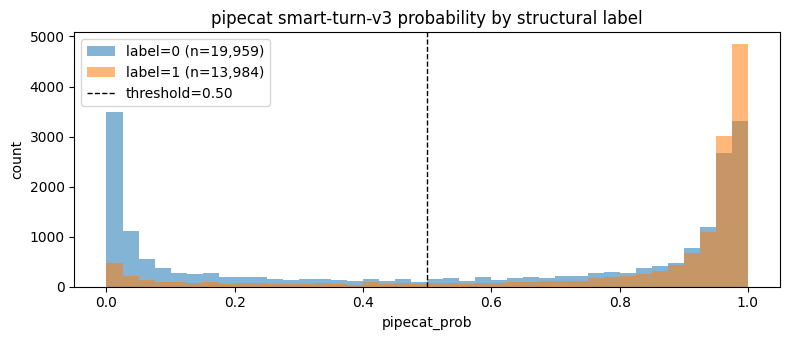

✅ histogram drawn


In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, 1, 41)
for lbl, color in [(0, "tab:blue"), (1, "tab:orange")]:
    sub = scored_ok[scored_ok["label"] == lbl]["pipecat_prob"]
    ax.hist(sub, bins=bins, alpha=0.55, label=f"label={lbl} (n={len(sub):,})", color=color)
ax.axvline(PIPECAT_THRESHOLD, color="k", linestyle="--", linewidth=1, label=f"threshold={PIPECAT_THRESHOLD:.2f}")
ax.set_xlabel("pipecat_prob")
ax.set_ylabel("count")
ax.set_title("pipecat smart-turn-v3 probability by structural label")
ax.legend()
fig.tight_layout()
plt.show()
print("✅ histogram drawn")

## Top-10 most-confident clips per direction

Same view as notebook 04's top-10 cell, but ranked by `pipecat_prob`.
Listen to a few from each end and compare the *audible* turn-yield /
mid-thought feel against what our zh model surfaced — if pipecat's
extremes sound cleaner, that's another vote for "our model is
undertrained, not broken."

In [16]:
from IPython.display import Audio, Markdown, display

TOP_K = 10

def load_clip(session_id: str, start_s: float, end_s: float):
    """Read just the [start_s, end_s) slice of a session WAV — no
    full-file decode (sf.read seeks via `start` / `frames`)."""
    path = WAV_DIR / f"{session_id}.wav"
    sr = sf.info(str(path)).samplerate
    start  = int(start_s * sr)
    frames = max(1, int((end_s - start_s) * sr))
    audio, _ = sf.read(str(path), start=start, frames=frames,
                       dtype="float32", always_2d=False)
    return audio, sr

def show_topk(title: str, rows: pd.DataFrame) -> None:
    display(Markdown(f"### {title}"))
    for rank, (_, row) in enumerate(rows.iterrows(), start=1):
        display(Markdown(
            f"**#{rank}**  prob=`{row['pipecat_prob']:.3f}`  "
            f"label=`{row['label']}`  source=`{row['source']}`  "
            f"session=`{row['session_id']}`  "
            f"clip=`[{row['clip_start_s']:.2f}, {row['clip_end_s']:.2f}]`  \n"
            f"text: {row['text']!r}"
        ))
        audio, sr = load_clip(
            row["session_id"],
            float(row["clip_start_s"]),
            float(row["clip_end_s"]),
        )
        display(Audio(audio, rate=sr))

scored_ranked = scored_ok.sort_values("pipecat_prob", ascending=False)
top_eot  = scored_ranked.head(TOP_K)
top_cont = scored_ranked.tail(TOP_K).iloc[::-1]

show_topk(f"Top {TOP_K} END_OF_TURN (highest pipecat_prob)", top_eot)
show_topk(f"Top {TOP_K} CONTINUATION (lowest pipecat_prob)",  top_cont)
print("✅ top-10 clips displayed")

### Top 10 END_OF_TURN (highest pipecat_prob)

**#1**  prob=`0.990`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-525`  clip=`[1465.01, 1467.65]`  
text: '那像打王者的话，他'

**#2**  prob=`0.990`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-105`  clip=`[1012.97, 1015.84]`  
text: '春秋战国也呃，进入萧'

**#3**  prob=`0.990`  label=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-528`  clip=`[478.86, 482.91]`  
text: '我就感觉啊，好多事情好像都是年龄越大，胆子越小'

**#4**  prob=`0.990`  label=`1`  source=`speaker_change`  session=`CTS-CN-F2F-2019-11-15-88`  clip=`[862.18, 864.42]`  
text: '三步一个。口鼻呼吸一次。'

...

**#7**  prob=`0.005`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-531`  clip=`[771.53, 777.57]`  
text: '就是同学应该是知一就知道，她因为她和我就是我就我跟'

**#8**  prob=`0.005`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-531`  clip=`[1100.93, 1102.30]`  
text: '就是刚开'

**#9**  prob=`0.005`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-808`  clip=`[1491.31, 1494.72]`  
text: '所以说呢呃我们应该去呃'

**#10**  prob=`0.005`  label=`0`  source=`intra_utterance_cut`  session=`CTS-CN-F2F-2019-11-15-531`  clip=`[438.53, 440.77]`  
text: '然后她是'

✅ top-10 clips displayed
